# Selfie Preprocessing

In this notebook, we will preprocess the selfie images for the face recognition task. This includes:
1. Loading selfie images from directory
2. Converting to grayscale
3. Resizing to 32x32 pixels (same as PIE dataset)
4. Normalizing pixel values
5. Splitting into training (7) and testing (3) sets
6. Visualizing preprocessing results

In [2]:
import os
import sys
import numpy as np
import traceback
from pathlib import Path
from typing import Tuple, List
from matplotlib import pyplot as plt
import json

# Add parent directory to path for imports
sys.path.append(str(Path().absolute().parent))

from src.data.data_loader import load_config

## Load Configuration and Set Seed

In [3]:
try:
    # Load configuration
    config = load_config()
    print(f"Using seed value: {config['seed']}")
    
    # Set random seeds for reproducibility
    np.random.seed(config['seed'])
    
except Exception as e:
    print(f"Error loading configuration: {e}")
    print(traceback.format_exc(limit=3))

Using seed value: 963


## Define Image Processing Functions

In [ ]:
import cv2
def load_and_preprocess_selfie(image_path: str,
                               target_size: Tuple[int, int] = (32, 32)) -> np.ndarray:
    """
    Load a single selfie image and preprocess it.
    
    Args:
        image_path: Path to the selfie image
        target_size: Target size for resizing (width, height)
    
    Returns:
        Preprocessed grayscale image as numpy array
    """
    try:
        #load image in grayscale
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")
        
        #resize and normalize
        img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        img_normalized = img_resized.astype(np.float32) / 255.0
        
        return img_normalized
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

In [9]:
def load_selfies_from_directory(selfie_dir: str) -> Tuple[np.ndarray, List[str]]:
    """
    Load and preprocess all selfie images from directory.
    
    Args:
        selfie_dir: Directory containing selfie images
    
    Returns:
        Tuple of (preprocessed_images, image_filenames)
    """
    try:
        if not os.path.exists(selfie_dir):
            raise FileNotFoundError(f"Selfie directory not found: {selfie_dir}")
        
        supported_extensions = ('.jpg', '.jpeg', '.png',)
        
        #get all supported extension images
        image_files = [f for f in os.listdir(selfie_dir) 
                      if f.lower().endswith(supported_extensions)]
        
        if len(image_files) == 0:
            raise ValueError(f"No images found in {selfie_dir}")
        
        print(f"Found {len(image_files)} images in {selfie_dir}")
        
        processed_images = []
        valid_filenames = []
        
        for filename in image_files:
            image_path = os.path.join(selfie_dir, filename)
            processed_img = load_and_preprocess_selfie(image_path)
            
            if processed_img is not None:
                processed_images.append(processed_img)
                valid_filenames.append(filename)
            
        if len(processed_images) == 0:
            raise ValueError("No valid images could be processed")
        
        return np.array(processed_images), valid_filenames
        
    except Exception as e:
        print(f"Error loading selfies from directory: {e}")
        print(traceback.format_exc(limit=3))
        return np.array([]), []

In [10]:
def split_selfies_train_test(selfies: np.ndarray, train_count: int = 7, 
                           test_count: int = 3) -> Tuple[np.ndarray, np.ndarray]:
    """
    Split selfie images into training and testing sets.
    
    Args:
        selfies: Array of preprocessed selfie images
        train_count: Number of images for training
        test_count: Number of images for testing
    
    Returns:
        Tuple of (training_selfies, testing_selfies)
    """
    try:
        total_needed = train_count + test_count
        if len(selfies) < total_needed:
            raise ValueError(f"Need at least {total_needed} selfies, got {len(selfies)}")
        
        #randomly shuffle for reproducible split
        indices = np.random.permutation(len(selfies))
        
        train_indices = indices[:train_count]
        test_indices = indices[train_count:train_count + test_count]
        
        train_selfies = selfies[train_indices]
        test_selfies = selfies[test_indices]
        
        return train_selfies, test_selfies
        
    except Exception as e:
        print(f"Error splitting selfies: {e}")
        print(traceback.format_exc(limit=3))
        return np.array([]), np.array([])

## Load and Preprocess Selfie Images

In [11]:
selfie_dir = "../Selfies and Images"
try:
    
    # Load and preprocess all selfies
    processed_selfies, selfie_filenames = load_selfies_from_directory(selfie_dir)
    
    print(f"Successfully processed {len(processed_selfies)} selfies:")
    print(f"Image shape: {processed_selfies.shape}")
    print(f"Pixel value range: [{processed_selfies.min():.3f}, {processed_selfies.max():.3f}]")
    print(f"Filenames: {selfie_filenames}")
    
except Exception as e:
    print(f"Error in selfie preprocessing: {e}")
    print(traceback.format_exc(limit=3))

Found 11 images in ../Selfies and Images
Successfully processed 11 selfies:
Image shape: (11, 32, 32)
Pixel value range: [0.020, 0.996]
Filenames: ['shared image (21).jpeg', 'shared image (23).jpeg', 'shared image (2).png', 'shared image (18).jpeg', 'shared image (22).jpeg', 'shared image (20).jpeg', 'shared image (19).jpeg', 'shared image (17).jpeg', 'shared image (15).jpeg', 'shared image (13).jpeg', 'shared image (14).jpeg']


## Split Selfies into Training and Testing Sets

In [12]:
try:
    if len(processed_selfies) > 0:
        
		#7|3 training and testing split
        train_selfies, test_selfies = split_selfies_train_test(processed_selfies)
        
        print(f"Training selfies: {train_selfies.shape}")
        print(f"Testing selfies: {test_selfies.shape}")
        
        #flatten images - compatibility with PIE dataset format
        train_selfies_flat = train_selfies.reshape(train_selfies.shape[0], -1)
        test_selfies_flat = test_selfies.reshape(test_selfies.shape[0], -1)
        
        print(f"Flattened training selfies: {train_selfies_flat.shape}")
        print(f"Flattened testing selfies: {test_selfies_flat.shape}")
    
except Exception as e:
    print(f"Error splitting selfies: {e}")
    print(traceback.format_exc(limit=3))

Training selfies: (7, 32, 32)
Testing selfies: (3, 32, 32)
Flattened training selfies: (7, 1024)
Flattened testing selfies: (3, 1024)


## Visualize Original vs Preprocessed Selfies

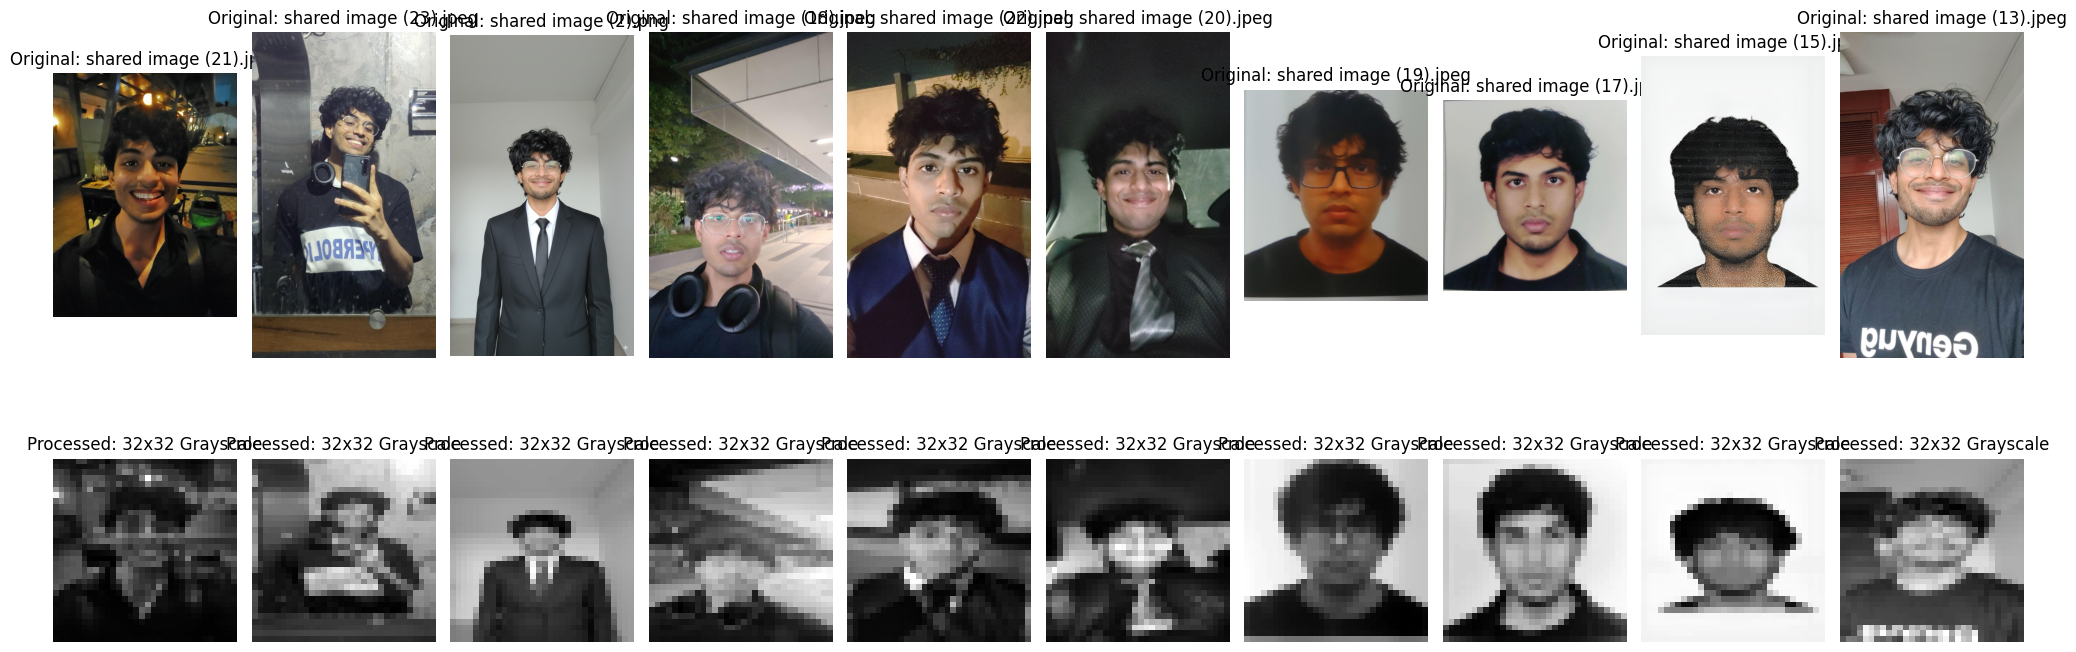

Preprocessing comparison saved to ../Outputs/selfies/preprocessing_comparison.png


In [13]:
os.makedirs('../Outputs/selfies', exist_ok=True)
try:
    if len(processed_selfies) > 0:
        
        #visualization
        n_images = min(10, len(processed_selfies))
        fig, axes = plt.subplots(2, n_images, figsize=(20, 8))
        
        if n_images == 1:
            axes = axes.reshape(2, 1)
        
        for i in range(n_images):
            
			#load original for comparison
            original_path = os.path.join(selfie_dir, selfie_filenames[i])
            original_img = cv2.imread(original_path)
            original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
            
            #display original
            axes[0, i].imshow(original_img)
            axes[0, i].set_title(f'Original: {selfie_filenames[i]}')
            axes[0, i].axis('off')
            
            #display preprocessed
            axes[1, i].imshow(processed_selfies[i], cmap='gray')
            axes[1, i].set_title(f'Processed: 32x32 Grayscale')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.savefig('../Outputs/selfies/preprocessing_comparison.png',
                    dpi=300,
                    bbox_inches='tight')
        plt.show()
        
        print("Preprocessing comparison saved to ../Outputs/selfies/preprocessing_comparison.png")
    
except Exception as e:
    print(f"Error visualizing selfies: {e}")
    print(traceback.format_exc(limit=3))

## Save Processed Selfie Data

In [15]:
os.makedirs('../Outputs/selfies', exist_ok=True)
try:
    
    # Save processed selfie data
    if len(train_selfies_flat) > 0 and len(test_selfies_flat) > 0:
        
        np.save('../Outputs/selfies/train_selfies.npy', train_selfies_flat)
        np.save('../Outputs/selfies/test_selfies.npy', test_selfies_flat)
        np.save('../Outputs/selfies/train_selfies_2d.npy', train_selfies)
        np.save('../Outputs/selfies/test_selfies_2d.npy', test_selfies)
        np.save('../Outputs/selfies/filenames.npy', selfie_filenames)
        
        print("Processed selfie data saved to ../Outputs/selfies/:")
        print(f"train_selfies.npy: {train_selfies_flat.shape} | test_selfies.npy: {test_selfies_flat.shape}")
        print(f"train_selfies_2d.npy: {train_selfies.shape} | test_selfies_2d.npy: {test_selfies.shape}")
        print(f"filenames.npy: {len(selfie_filenames)} filenames")
    
except Exception as e:
    print(f"Error saving selfie data: {e}")
    print(traceback.format_exc(limit=3))

Processed selfie data saved to ../Outputs/selfies/:
train_selfies.npy: (7, 1024) | test_selfies.npy: (3, 1024)
train_selfies_2d.npy: (7, 32, 32) | test_selfies_2d.npy: (3, 32, 32)
filenames.npy: 11 filenames
